# Real-data method comparison (package client)

This notebook compares Binary VQE, QAOA X, QAOA XY, Fractional VQE, and classical baselines on one market-data window. It delegates method execution and baseline evaluation to package helpers, then writes a CSV and plots the resulting rows.

Requires the optional data extras:

```bash
pip install -e ".[data]"
```

In [1]:
from __future__ import annotations

import csv
import importlib
import sys
from pathlib import Path

from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not locate repository root containing pyproject.toml.")


ROOT = find_repo_root(Path.cwd().resolve())
for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

vqe_portfolio = importlib.import_module("vqe_portfolio")
plotting = importlib.import_module("vqe_portfolio.plotting")
real_data_comparison_rows = vqe_portfolio.real_data_comparison_rows
plot_comparison_metric_bars = plotting.plot_comparison_metric_bars
plot_risk_return_comparison = plotting.plot_risk_return_comparison

OUTPUT_CSV = ROOT / "results" / "real_data_method_comparison.csv"
IMAGE_DIR = ROOT / "notebooks" / "images"

## Configuration

In [2]:
TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN"]
START = "2024-01-01"
END = "2025-01-01"

LAM = 4.0
ALPHA = 5.0
K = 2
SEED = 0
STEPS = 25
SHOTS = 512

## Run package comparison

In [3]:
rows, prices = real_data_comparison_rows(
    TICKERS,
    start=START,
    end=END,
    lam=LAM,
    alpha=ALPHA,
    k=K,
    seed=SEED,
    steps=STEPS,
    shots=SHOTS,
    shrink="lw",
    scale="none",
)

display(
    Markdown(
        f"Loaded `{len(prices)}` price rows and produced `{len(rows)}` comparison rows."
    )
)

Loaded `261` price rows and produced `7` comparison rows.

## Save and display comparison

In [4]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_CSV.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)


def markdown_table(rows: list[dict[str, str]], columns: list[str]) -> Markdown:
    header = "| " + " | ".join(columns) + " |"
    rule = "| " + " | ".join("---" for _ in columns) + " |"
    body = [
        "| " + " | ".join(str(row.get(col, "")) for col in columns) + " |"
        for row in rows
    ]
    return Markdown("\n".join([header, rule, *body]))


display(Markdown(f"Wrote `{OUTPUT_CSV}`."))
display(
    markdown_table(
        rows,
        [
            "method",
            "type",
            "objective_family",
            "reported_weighting",
            "selection_or_weights",
            "return",
            "risk",
            "objective",
            "feasible_rate",
        ],
    )
)

Wrote `/workspaces/VQE_Portfolio_Optimization/results/real_data_method_comparison.csv`.

| method | type | objective_family | reported_weighting | selection_or_weights | return | risk | objective | feasible_rate |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Classical exhaustive search | classical | binary_qubo | equal_weight_selected | AAPL, AMZN | 0.331913 | 0.204359 | 0.004376 | 1.000000 |
| Classical equal weight | classical heuristic | fractional_simplex | simplex_weights | [0.250000 0.250000 0.250000 0.250000] | 0.447278 | 0.228856 | -0.237777 | 1.000000 |
| Classical exact Markowitz | classical | fractional_simplex | simplex_weights | [0.430361 0.000000 0.397103 0.172536] | 0.585289 | 0.269164 | -0.295493 | 1.000000 |
| Binary VQE best feasible | quantum | binary_qubo | equal_weight_selected | AAPL, MSFT | 0.213054 | 0.180646 | 0.096018 | 0.970703 |
| QAOA X best feasible | quantum | binary_qubo | equal_weight_selected | AAPL, AMZN | 0.331913 | 0.204359 | 0.004376 | 0.634766 |
| QAOA XY best feasible | quantum | binary_qubo | equal_weight_selected | AAPL, MSFT | 0.213054 | 0.180646 | 0.096018 | 1.000000 |
| Fractional VQE | quantum | fractional_simplex | simplex_weights | [0.416594 0.007169 0.414146 0.162091] | 0.595258 | 0.274312 | -0.294270 | 1.000000 |

## Plots

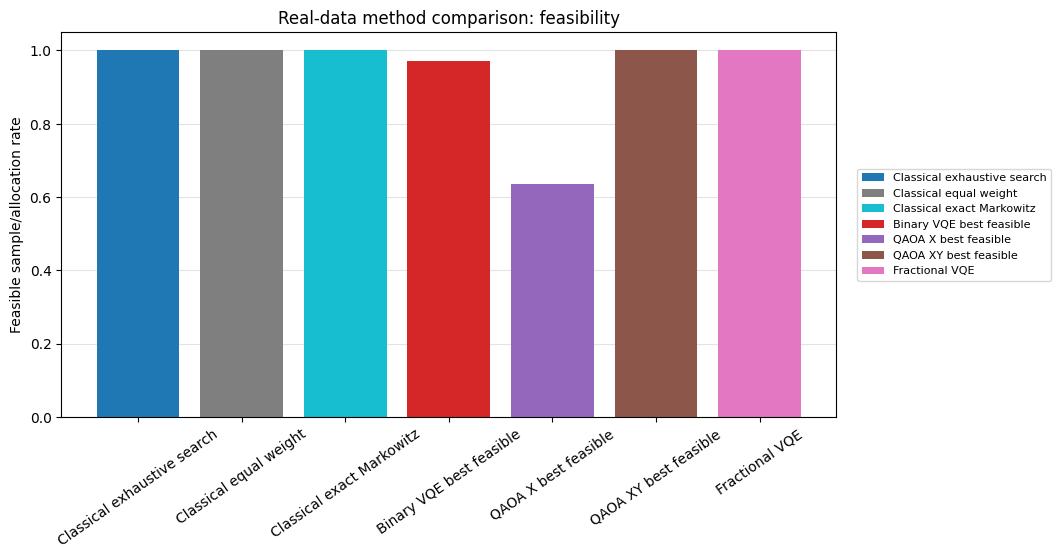

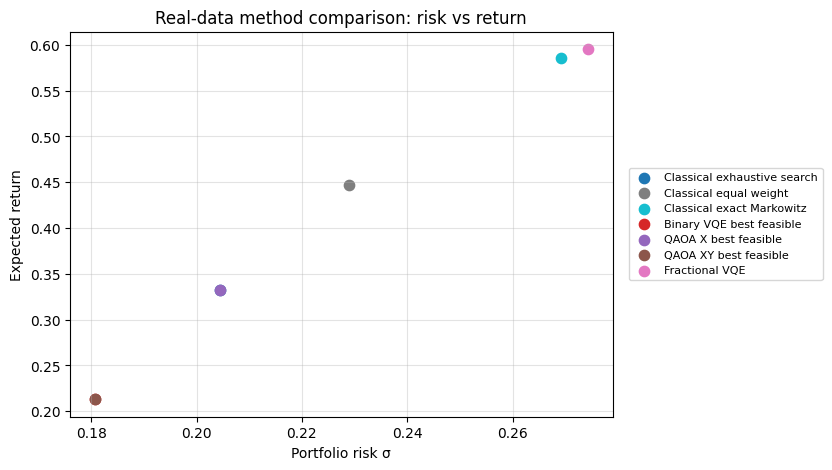

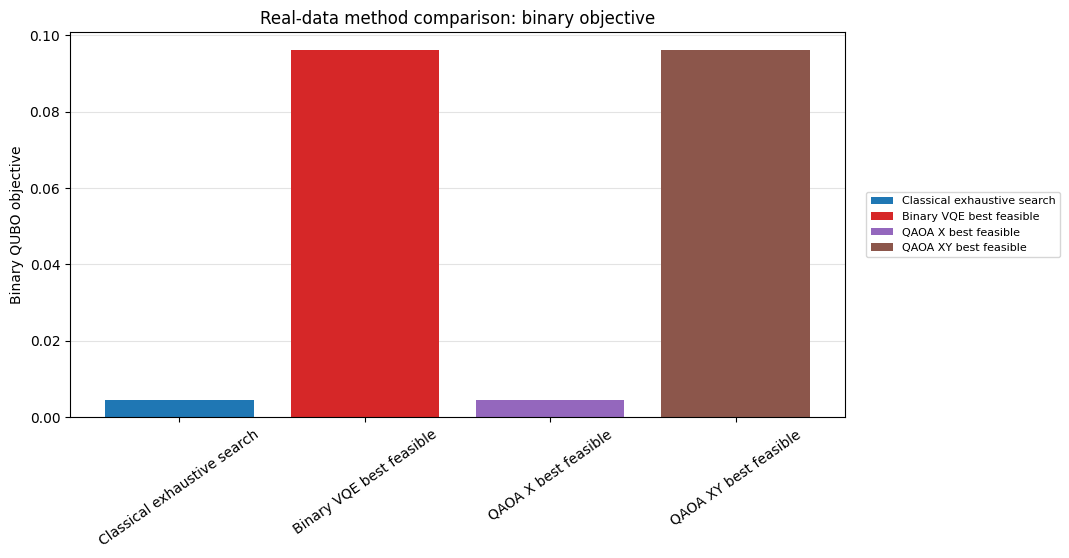

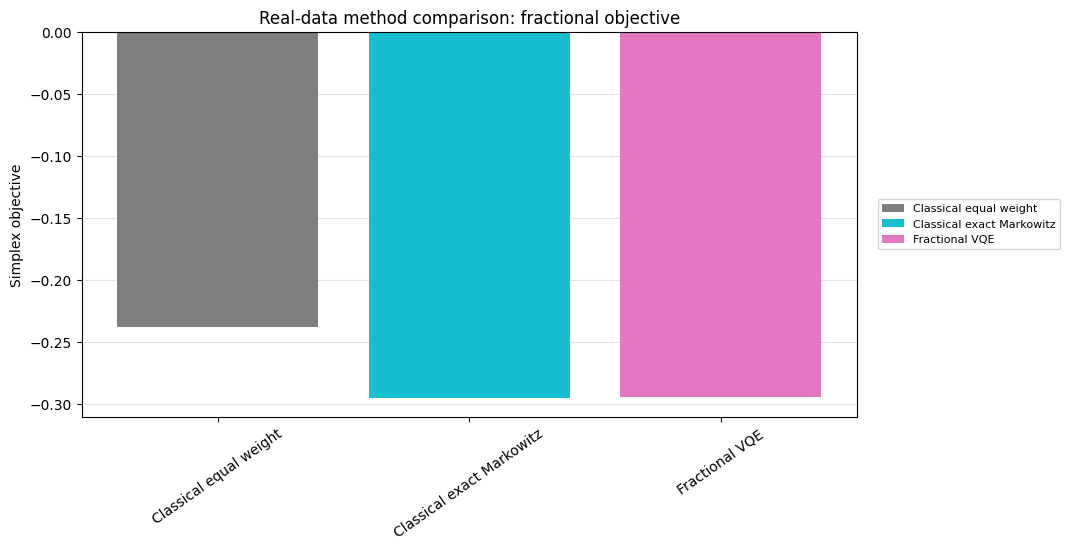

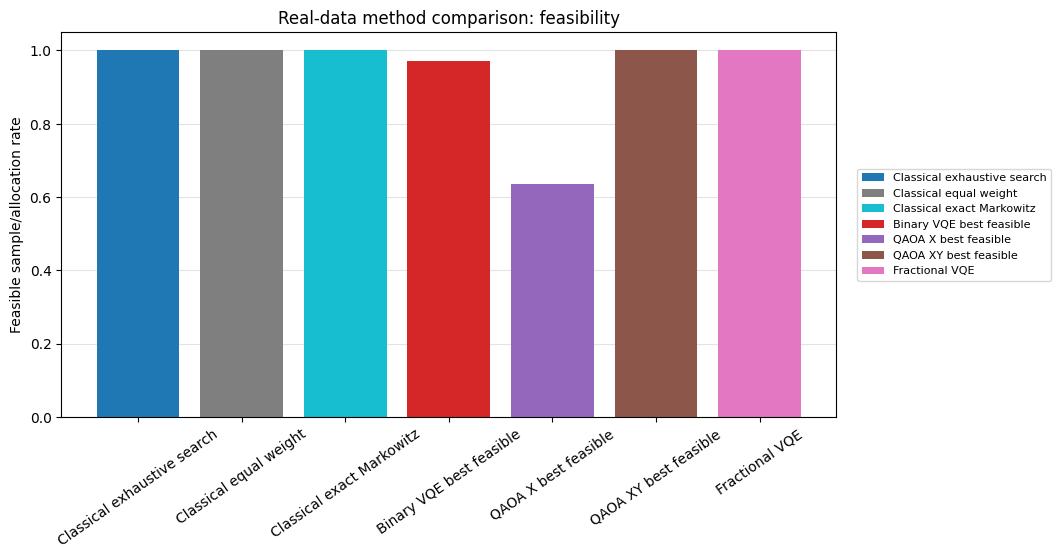

In [5]:
plot_risk_return_comparison(
    rows,
    title="Real-data method comparison: risk vs return",
    outpath=IMAGE_DIR / "Real_Data_Method_Comparison_Risk_Return.png",
)

binary_rows = [row for row in rows if row["objective_family"] == "binary_qubo"]
fractional_rows = [
    row for row in rows if row["objective_family"] == "fractional_simplex"
]

plot_comparison_metric_bars(
    binary_rows,
    metric="objective",
    ylabel="Binary QUBO objective",
    title="Real-data method comparison: binary objective",
    outpath=IMAGE_DIR / "Real_Data_Method_Comparison_Binary_Objective.png",
)

plot_comparison_metric_bars(
    fractional_rows,
    metric="objective",
    ylabel="Simplex objective",
    title="Real-data method comparison: fractional objective",
    outpath=IMAGE_DIR / "Real_Data_Method_Comparison_Fractional_Objective.png",
)

plot_comparison_metric_bars(
    rows,
    metric="feasible_rate",
    ylabel="Feasible sample/allocation rate",
    title="Real-data method comparison: feasibility",
    outpath=IMAGE_DIR / "Real_Data_Method_Comparison_Feasibility.png",
)